In [101]:
import pandas as pd
import numpy as np
from helper import visualize_input, plot_images
from matplotlib import pyplot as plt
import math

In [102]:
df = pd.read_csv('alturas-pesos.csv')

In [103]:
features_matrix = np.zeros((len(df),2))
labels = np.empty((len(df)), dtype=object)

for i, person in enumerate(df.values):
    features_matrix[i, 0] = person[2] # altura
    features_matrix[i, 1] = person[1] # peso
    labels[i] = person[0]

men_means = features_matrix[labels=='Hombre',:].mean(axis=0)
women_means = features_matrix[labels=='Mujer',:].mean(axis=0)
men_vars = features_matrix[labels=='Hombre',:].var(axis=0, ddof=1)
women_vars = features_matrix[labels=='Mujer',:].var(axis=0, ddof=1)

print('medias de los hombres:', men_means)
print('varianzas de los hombres:', men_vars)
print('medias de las mujeres:', women_means)
print('varianzas de las mujeres:', women_vars)

medias de los hombres: [174.823  84.343]
varianzas de los hombres: [52.85984297 80.61147329]
medias de las mujeres: [161.3236  61.1248]
varianzas de las mujeres: [47.13591022 74.53293155]


In [104]:
def gaussian(x, mu, sig):
    return np.exp(-np.power((x - mu)/sig, 2.)/2)/(np.sqrt(2.*np.pi)*sig)

def plot_gaussian(mu=0, sig= 1, points = 200, N = 2, marker=None, label = None, x = None, color = None, 
                  x_label='',y_label='',ax = None, figsize = (20,10), center_label_tick = None):
    if ax is None:
        f, ax = plt.subplots(1, 1, sharey=True, sharex=True, figsize = figsize)
    if x is None:
        x = np.linspace(mu-N*sig, mu+N*sig, points)
    y = gaussian(x, mu, sig)
    ax.plot(x,y, marker = marker, label = label, color = color)
    ax.set_ylabel(y_label)
    ax.set_xlabel(x_label)

    if center_label_tick is not None:
        labels = [item.get_text() for item in ax.get_xticklabels()]
        labels[int((len(labels)-1)/2)] = center_label_tick
        ax.set_xticklabels(labels)

    return x, y

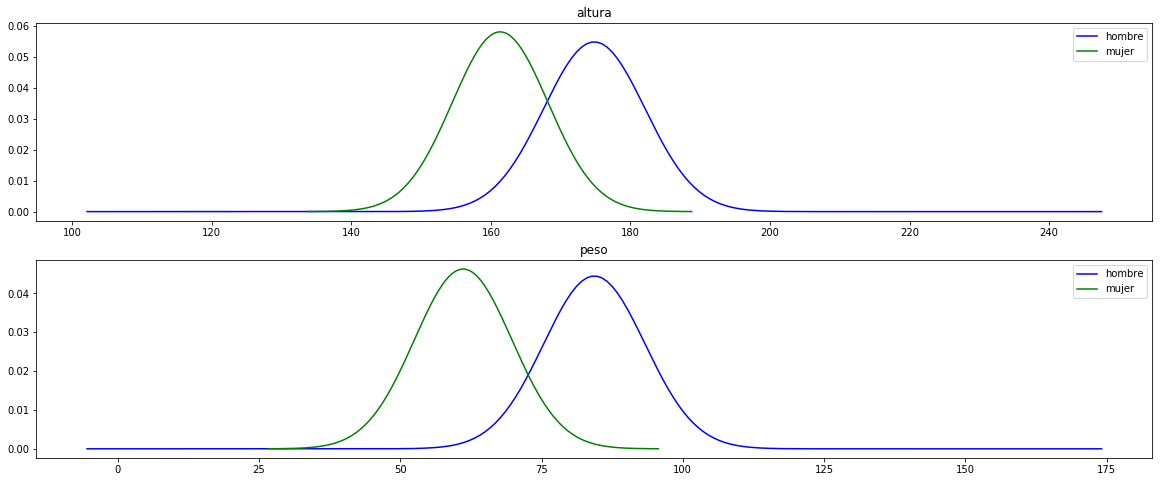

In [105]:
f, axs = plt.subplots(2, 1, sharey=False, sharex=False, figsize = (20,8))
keys = ['altura', 'peso']
for i, ax in enumerate(axs):
    plot_gaussian(men_means[i], np.sqrt(men_vars[i]), ax=ax, N=10, color='b', label='hombre')
    plot_gaussian(women_means[i], np.sqrt(women_vars[i]), ax=ax, N=4, color='g', label='mujer')
    ax.title.set_text(keys[i])
    ax.legend()
plt.show()

> como era esperable las distribuciones de peso y altura corresponden con la distribución normal

## Gaussian Naive Bayes

In [106]:
sample = np.array([180,90])

In [107]:
p_hombre = len(features_matrix[labels=='Hombre',:])/len(features_matrix)
p_altura_hombre = gaussian(sample[0], men_means[0], np.sqrt(men_vars[0]))
p_peso_hombre = gaussian(sample[1], men_means[1], np.sqrt(men_vars[1]))
posterior_hombre = p_hombre*p_altura_hombre*p_peso_hombre
print('Posteriori de hombre:', posterior_hombre)

Posteriori de hombre: 0.0007757556389583803


In [108]:
p_mujer = len(features_matrix[labels=='Mujer',:])/len(features_matrix)
p_altura_mujer = gaussian(sample[0], women_means[0], np.sqrt(women_vars[0]))
p_peso_mujer = gaussian(sample[1], women_means[1], np.sqrt(women_vars[1]))
posterior_mujer = p_mujer*p_altura_mujer*p_peso_mujer
print('Posteriori de Mujer:', posterior_mujer)

Posteriori de Mujer: 1.235607374878039e-07


In [109]:
if posterior_mujer>posterior_hombre:
    print('MUJER')
else:
    print('HOMBRE')

HOMBRE


## Gausian Naive Bayes usando Sklearn

In [110]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
y_pred = gnb.fit(features_matrix, labels)

samples = np.array([sample, [160, 70], [178, 73], [178, 74], [155, 50]])
print('predicciones:')
print(y_pred.predict(samples))
print()
print('probabilidades:')
print(y_pred.predict_proba(samples))


predicciones:
['Hombre' 'Mujer' 'Hombre' 'Hombre' 'Mujer']

probabilidades:
[[9.99841029e-01 1.58971186e-04]
 [5.19360037e-02 9.48063996e-01]
 [9.48172115e-01 5.18278847e-02]
 [9.61104849e-01 3.88951514e-02]
 [5.13625380e-05 9.99948637e-01]]
